## Transfer Learning

On effectuera un model basé sur le model ResNet50

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [4]:
#ResNet a été entraîné sur des images de taille 224x224, nous allons donc redimensionner nos images à cette taille.
TAILLE_IMG = (224, 224)
ROOT = "../data/clean/"

transform_train = transforms.Compose([
    transforms.Resize(TAILLE_IMG),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #normalisation des images selon les statistiques de ImageNet
])

transform_all = transforms.Compose([
    transforms.Resize(TAILLE_IMG),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #normalisation des images selon les statistiques de ImageNet
])

# Datasets et DataLoaders
train_dataset = datasets.ImageFolder(root=ROOT + '/train', transform=transform_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)

test_dataset = datasets.ImageFolder(root=ROOT + '/test', transform=transform_all)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

val_dataset = datasets.ImageFolder(root=ROOT + '/val', transform=transform_all)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

In [5]:
model_tl = models.resnet50(weights= models.ResNet50_Weights.DEFAULT) # Charger les poids pré-entraînés de ResNet-50
num_features = model_tl.fc.in_features # Obtenir le nombre de caractéristiques d'entrée de la dernière couche fully connected
model_tl.fc = nn.Linear(num_features, 2) # Remplacer la dernière couche
PATH_MODEL = "../models"

In [ ]:

def train_loop(model, train_loader, val_loader, num_epochs, patience, learn_rate, requires_grad=False):

    model.to(device) #on charge sur le GPU
    if not requires_grad:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():  # Seules les couches fully connected sont entraînables
            param.requires_grad = True

    trainable_params = [p for p in model.parameters() if p.requires_grad]   #on prend juste les couches qu'on va entrainée pour que l'optimiseur 
                                                                            #n'alloue pas de mémoire pour les autres
    optimizer = torch.optim.Adam(trainable_params, lr=learn_rate)
    criterion = nn.CrossEntropyLoss()
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    best_val_loss = float('inf')
    patience_counter = 0

    
    for epoch in range(num_epochs):

        model.train()
        train_loss = 0.0
        train_correct = 0
        total_train = 0

        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            train_loss += loss.item() #on ajoute l'erreur de ce batch à la perte totale de l'epoch
            _, predicted = torch.max(outputs.data, 1) #prediction de la classe (chat = 0, chien = 1)
            total_train += labels.size(0) #nombre total d'images traitées
            train_correct += (predicted == labels).sum().item()
        
        train_loss = train_loss / len(train_loader) #on divise la perte totale par le nombre de batchs pour obtenir la perte moyenne par batch
        train_accuracy = train_correct / total_train
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
    
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.4f}')
        print(f'Validation Accuracy: {val_accuracy:.4f}, Loss: {val_loss:.4f}')

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(PATH_MODEL, f'tl_model.pth')) #sauvegarde du meilleur modèle dans dossier models
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping")
            break
    return train_losses, val_losses, train_accuracies, val_accuracies #retour des listes des pertes et précisions pour les courbes d'apprentissage

In [11]:
def visualization(p1,p2):
    # p1 et p2 sont les tuples (train_losses, val_losses, train_acc, val_acc)
 
    # Fusion des listes
    all_train_losses = p1[0] + p2[0]
    all_val_losses = p1[1] + p2[1]
    all_train_acc = p1[2] + p2[2]
    all_val_acc = p1[3] + p2[3]
         
    transition_epoch = len(p1[0]) # L'endroit où commence la phase 2
    plt.figure(figsize=(15, 6))
    # Graphique des Pertes (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(all_train_losses, label='Train Loss', color='blue')
    plt.plot(all_val_losses, label='Val Loss', color='orange')
    plt.axvline(x=transition_epoch-1, color='red', linestyle='--', label='Début Fine-tuning')
    plt.title('Fusion des Pertes (Phase 1 + Phase 2)')
    plt.xlabel('Époques totales')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Graphique de la Précision (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(all_train_acc, label='Train Acc', color='green')
    plt.plot(all_val_acc, label='Val Acc', color='red')
    plt.axvline(x=transition_epoch-1, color='blue', linestyle='--', label='Début Fine-tuning')
    plt.title('Fusion des Précisions (Phase 1 + Phase 2)')
    plt.xlabel('Époques totales')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Epoch 1/100, Loss: 0.2613, Accuracy: 0.9490
Validation Accuracy: 0.9836, Loss: 0.1155
Epoch 2/100, Loss: 0.1104, Accuracy: 0.9741
Validation Accuracy: 0.9868, Loss: 0.0722
Epoch 3/100, Loss: 0.0810, Accuracy: 0.9783
Validation Accuracy: 0.9888, Loss: 0.0532
Epoch 4/100, Loss: 0.0683, Accuracy: 0.9803
Validation Accuracy: 0.9896, Loss: 0.0442
Epoch 5/100, Loss: 0.0631, Accuracy: 0.9807
Validation Accuracy: 0.9908, Loss: 0.0397
Epoch 6/100, Loss: 0.0569, Accuracy: 0.9817
Validation Accuracy: 0.9904, Loss: 0.0360
Epoch 7/100, Loss: 0.0510, Accuracy: 0.9841
Validation Accuracy: 0.9904, Loss: 0.0343
Epoch 8/100, Loss: 0.0474, Accuracy: 0.9851
Validation Accuracy: 0.9908, Loss: 0.0319
Epoch 9/100, Loss: 0.0465, Accuracy: 0.9840
Validation Accuracy: 0.9912, Loss: 0.0313
Epoch 10/100, Loss: 0.0457, Accuracy: 0.9848
Validation Accuracy: 0.9924, Loss: 0.0298
Epoch 11/100, Loss: 0.0455, Accuracy: 0.9845
Validation Accuracy: 0.9908, Loss: 0.0296
Epoch 12/100, Loss: 0.0433, Accuracy: 0.9857
Validat

C:\Users\abdal\AppData\Local\Temp\ipykernel_20556\2029761622.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_tl.load_state_dict(torch.load(os.path.join(PATH_MODEL,

Epoch 1/100, Loss: 0.0344, Accuracy: 0.9875
Validation Accuracy: 0.9908, Loss: 0.0256
Epoch 2/100, Loss: 0.0339, Accuracy: 0.9879
Validation Accuracy: 0.9912, Loss: 0.0259
Epoch 3/100, Loss: 0.0327, Accuracy: 0.9899
Validation Accuracy: 0.9924, Loss: 0.0248
Epoch 4/100, Loss: 0.0337, Accuracy: 0.9884
Validation Accuracy: 0.9912, Loss: 0.0247
Epoch 5/100, Loss: 0.0315, Accuracy: 0.9896
Validation Accuracy: 0.9908, Loss: 0.0256
Epoch 6/100, Loss: 0.0312, Accuracy: 0.9891
Validation Accuracy: 0.9920, Loss: 0.0245
Epoch 7/100, Loss: 0.0316, Accuracy: 0.9892
Validation Accuracy: 0.9912, Loss: 0.0258
Epoch 8/100, Loss: 0.0356, Accuracy: 0.9871
Validation Accuracy: 0.9908, Loss: 0.0256
Epoch 9/100, Loss: 0.0319, Accuracy: 0.9892
Validation Accuracy: 0.9904, Loss: 0.0269
Epoch 10/100, Loss: 0.0323, Accuracy: 0.9890
Validation Accuracy: 0.9920, Loss: 0.0254
Epoch 11/100, Loss: 0.0327, Accuracy: 0.9886
Validation Accuracy: 0.9924, Loss: 0.0250
Early stopping


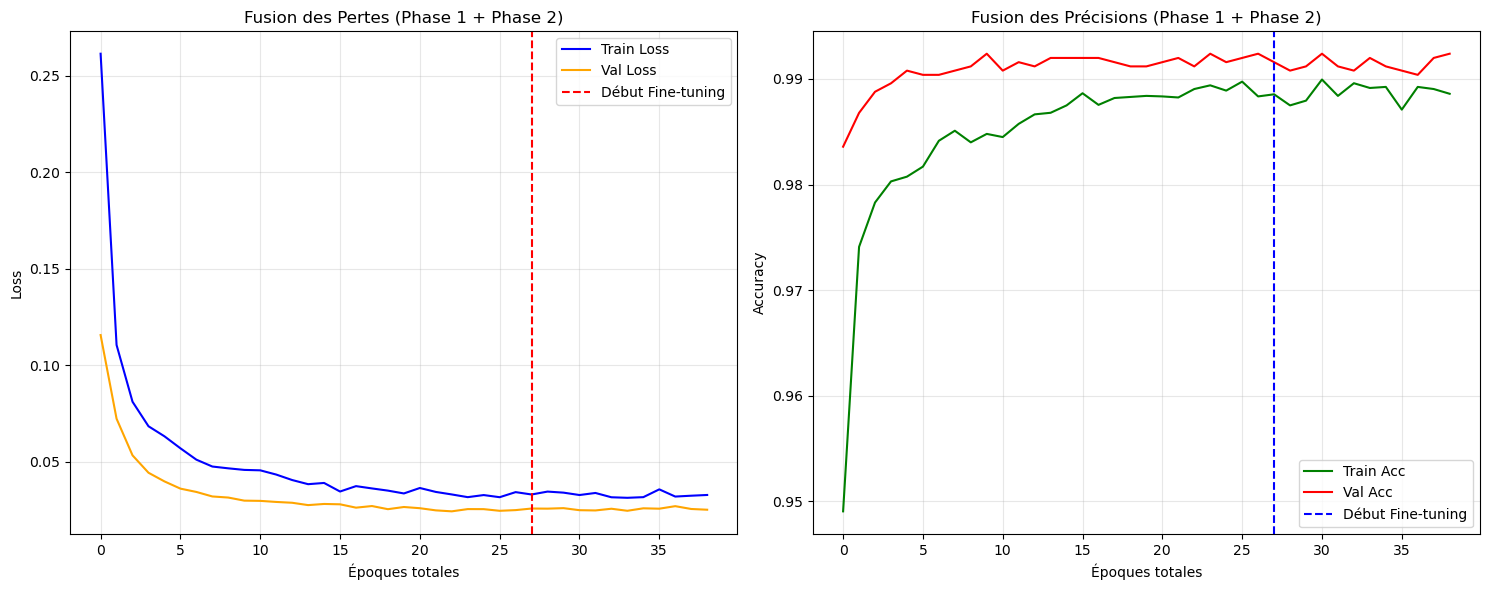

In [12]:
p1 = train_loop(model_tl, train_loader, val_loader, num_epochs=100, patience=5, learn_rate=0.0001, requires_grad=False) #phase 1 : on entraîne juste les couches fully connected
model_tl.load_state_dict(torch.load(os.path.join(PATH_MODEL, 'tl_model.pth'))) #chargement du meilleur modèle sauvegardé
p2 = train_loop(model_tl, train_loader, val_loader, num_epochs=100, patience=5, learn_rate=0.00001, requires_grad=True) #phase 2 : on entraîne tout le modèle

visualization(p1,p2)

## évaluation sur le slot de Test

C:\Users\abdal\AppData\Local\Temp\ipykernel_22936\3647059466.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_tl.load_state_dict(torch.load(os.path.join(PATH_MODEL

,Model,Accuracy,Time per Image (s)
0,Transfer Learning,0.991607,0.010593


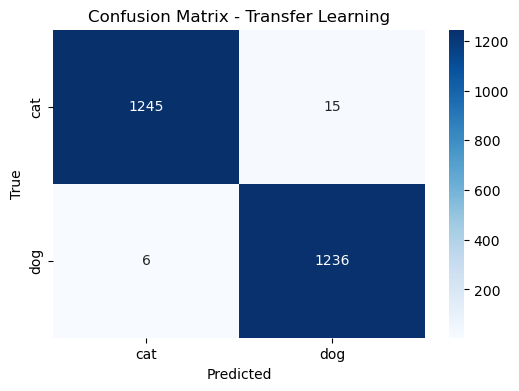

Classification Report:
               precision    recall  f1-score   support

         cat       1.00      0.99      0.99      1260
         dog       0.99      1.00      0.99      1242

    accuracy                           0.99      2502
   macro avg       0.99      0.99      0.99      2502
weighted avg       0.99      0.99      0.99      2502



In [6]:
import time #Ajout de la bibliothèque time pour mesurer le temps d'évaluation
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

def evaluate_model(model, dataloader):
    model.to(device)
    model.eval()
    all_preds, all_labels, errors = [], [], []
    correct, total, accuracy = 0, 0, 0
    start_time = time.time()
    with torch.no_grad():
        
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
                # Enregistrer les erreurs de classification
            for i in range(len(labels)):
                if (predicted[i] != labels[i]) and (len(errors) < 10):  # Limiter à 10 erreurs pour l'affichage
                    errors.append({'image': images[i].cpu(), 'label': labels[i].item(), 'pred': predicted[i].item()})
    end_time = time.time()
    images_time = (end_time - start_time) / total  # Temps moyen par image
    accuracy = correct / total
    return accuracy, images_time, errors, all_preds, all_labels


def confusion_matrix_and_report(labels, preds, model_name):
    cm = confusion_matrix(labels, preds)
    report = classification_report(labels, preds, target_names=['cat', 'dog'])
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['cat', 'dog'], yticklabels=['cat', 'dog'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    
    print("Classification Report:\n", report)

model_tl.load_state_dict(torch.load(os.path.join(PATH_MODEL, 'tl_model.pth'))) #chargement du meilleur modèle sauvegardé

result_tl = evaluate_model(model_tl, test_loader)

data = {
    'Model': ['Transfer Learning'],
    'Accuracy': [result_tl[0]],
    'Time per Image (s)': [result_tl[1]]
}

df = pd.DataFrame(data)
display(df)

confusion_matrix_and_report(result_tl[3], result_tl[4], "Transfer Learning")
